# Paso 1: Abrimos el archivo de datos

In [22]:
# colocamos todas las librerías a emplear en el presente proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [23]:
# leemos el dataset y lo colocamos en un dataframe
df = pd.read_csv('../../datasets/users_behavior.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB


se verifica que no existen valores nulos en cada una de las columnas o atributos del dataframe. Se aprecia además que existen tipos de valores float en los atributos 'calls' y 'messages', deberían ser tipo int.

In [24]:
# Comprobamos la variable calls y messages para convertir de float a int.
convert_to_int_calls=np.array_equal(df['calls'], df['calls'].astype('int'))
convert_to_int_messages=np.array_equal(df['messages'], df['messages'].astype('int'))
print(convert_to_int_calls, convert_to_int_messages)

True True


se verificó que las columnas pueden cambiarse a un tipo int.

In [25]:
# se cambia los tipos de datos de float a int en las columnas mencionadas
df['calls'] = df['calls'].astype('int')
df['messages'] = df['messages'].astype('int')

los datos se encuentran limpios para usarse en el análisis

# Paso 2. Se segmenta los datos fuente en un conjunto de entrenamiento, uno de validación y uno de prueba.

In [26]:
# extraemos la columna is_ultra porque es el target u objetivo. Además, se coloca el parámetro axis para seleccionar columna.
features = df.drop(['is_ultra'], axis=1)
target = df['is_ultra']

In [27]:
# se segmenta la data en los conjuntos entrenamiento y prueba. Se emplea un 20% para el dataframe de prueba.
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.20, random_state=14)

# se segmenta la data en los conjuntos entrenamiento y validación. Se emplea un test_size=0.25 para obtener el 20% del df original.
features_train, features_val, target_train, target_val = train_test_split(
    features_train, target_train, test_size=0.25, random_state=14)

In [28]:
# se comprueba que el df_train es el 60% del df original
train_percent=features_train.shape[0]/df.shape[0]
# se comprueba que el df_valid es el 20% del df original
val_percent=features_val.shape[0]/df.shape[0]
# se comprueba que el df_test es el 20% del df original
test_percent=features_test.shape[0]/df.shape[0]
print(train_percent*100,val_percent*100,test_percent*100)

59.98755444928439 20.00622277535781 20.00622277535781


se comprueban los datos del 60% para los entrenamientos, 20% para las pruebas y 20% para las validaciones

# Paso 3. Se investiga la calidad de diferentes modelos cambiando los hiperparámetros.

### Desarrolla un modelo con la mayor exactitud posible. En este proyecto, el umbral de exactitud es 0.75. Usa el dataset para comprobar la exactitud.

- El objetivo es clasificar a los nuevos usuarios en alguno de los planes: Smart o Ultra. También, se quiere que la exactitud de los datos del modelo sea la mayor posible.
- Se analizan los modelos para clasificar como los el árbol de decisión y bosques aleatorios.
- Se analiza en un bucle la profundidad óptima con la cual la exactitud cumpla con el umbral establecido, ya que el hiperparámetro más importante de un árbol de decisión es max_depth.
- Se analiza en un bucle el número de estimadores óptimos con la cual la exactitud cumpla con el umbral establecido, ya que el hiperparámetro más importante de un bosque aleatorio es es mn_estimators.

In [29]:
# se emplea el modelo de arbol de decisión
best_score = 0
best_est = 0
for depth in range(1, 11): # se establece un rango de 10 de profundidad para verificar como varía la exactitud.
    model = DecisionTreeClassifier(max_depth=depth,random_state=14, min_samples_split=10, min_samples_leaf=5)
    # entrenamos el modelo en el conjunto de entrenamiento
    model.fit(features_train, target_train)
    train_predictions = model.predict(features_train)
    # calcula la puntuación de accuracy en el conjunto de validación
    score = model.score(features_val, target_val)
    if score > best_score:
        best_score = score
        best_depth = depth
print(
    f"La exactitud del mejor modelo en el conjunto de validación (depth = {best_depth}): {best_score}")

La exactitud del mejor modelo en el conjunto de validación (depth = 7): 0.7962674961119751


- Se considera la exactitud del conjunto de validación porque mide como se comportará el modelo con nueva data. En cambio, la exactitud de la data de entranamiento mide como el modelo se comporta con la data de entrenamiento, un valor alto de este valor no quiere decir que es un buen modelo. Por ese motivo se toma la exactitud del conjunto de validación
- Además, se aprecia una profundidad de 7. Esto podría generar un sobreajuste del modelo, lo cual no es del todo recomendable. Sin embargo de acuerdo a lo solicitado por el proyecto, se elije la mayor exactitud posible.
- Se establece que el hiperparámetro max_depth tendrá un valor de 7 para nuestro modelo. 

In [30]:
# se emplea el modelo de bosques aleatorios
best_score = 0
best_est = 0
for est in range(1, 100): # se establece un rango de 20 de estimadores para verificar el numero de estimadores para obtener la exactitud más elevada.
    model = RandomForestClassifier(random_state=15, n_estimators=est, min_samples_split=10, min_samples_leaf=5)
    # entrena el modelo en el conjunto de entrenamiento
    model.fit(features_train, target_train)
    # calcula la puntuación de accuracy en el conjunto de validación
    score = model.score(features_val, target_val)
    if score > best_score:
        best_score = score
        best_est = est  # guarda el número de estimadores que corresponden a la mejor puntuación de exactitud
print(
    f"La exactitud del mejor modelo en el conjunto de validación (n_estimators = {best_est}): {best_score}")

La exactitud del mejor modelo en el conjunto de validación (n_estimators = 59): 0.80248833592535


- Como ya se sabía, los bosques aleatorios proporcionan mayor exactitud. La cantidad de estimadores no ha sido elevada a comparación del valor por default. 
- Los bosques no pueden sobreajustarse debido a que tienen demasiados árboles. Si bien el sobreajuste de un bosque aún puede ocurrir este efecto generalmente se ve compensado por el beneficio de tener muchos árboles.
- Se establece que el hiperparámetro n_estimators tendrá un valor de 59 para nuestro modelo.

# Paso 4. Se comprueba la calidad del modelo usando el conjunto de prueba.

### Se entrena cada modelo para obtener la cantidad de errores que genera y la exactitud que presenta.

In [31]:
# Empleamos el modelo de arbol de decisiones en el conjunto de entrenamiento
model_tree = DecisionTreeClassifier(max_depth=7,random_state=16, min_samples_split=10, min_samples_leaf=5) # min_samples_split=10, min_samples_leaf=5 ayudan a reducir el ruido entre los datos.
model_tree.fit(features_train, target_train)
# Predecimos los valores target para los datos de prueba (test)
test_predictions = model_tree.predict(features_test)
def error_count(answers, predictions):
    count = 0
    for i in range(len(answers)):
        if answers[i] != predictions[i]:
            count += 1
    return count
# Calculamos errores en el conjunto de prueba
print('Errores:', error_count(target_test.values, test_predictions))
# Calculamos la métrica de exactitud en el conjunto de prueba
accuracy = accuracy_score(target_test, test_predictions)
print(f'Exactitud: {accuracy:.4f}')

Errores: 123
Exactitud: 0.8087


In [32]:
# Empleamos el modelo de bosque aleatorios en el conjunto de entrenamiento
model_forest = RandomForestClassifier(random_state=14, n_estimators=59, min_samples_split=10, min_samples_leaf=5) # min_samples_split=10, min_samples_leaf=5 ayudan a reducir el ruido entre los datos.
model_forest.fit(features_train, target_train)
# Predecimos los valores target para los datos de prueba (test)
test_predictions = model_forest.predict(features_test)
def error_count(answers, predictions):
    count = 0
    for i in range(len(answers)):
        if answers[i] != predictions[i]:
            count += 1
    return count
# Calculamos errores en el conjunto de prueba
print('Errores:', error_count(target_test.values, test_predictions))
# Calculamos la métrica de exactitud en el conjunto de prueba
accuracy = accuracy_score(target_test, test_predictions)
print(f'Exactitud: {accuracy:.4f}')

Errores: 115
Exactitud: 0.8212


- El modelo seleccionado es el RandomForestClassifier con una cantidad de estimadores de 59.
- se cumple con desarrollar un modelo con la mayor exactitud posible. Se pasó el umbral establecido en el problema de 0.75 alcanzando un valor de 0.82 con la cantidad de errores de 115 de 3214 dando un porcentaje de error de 3.5%, considerandolo bajo para los fines que se han definido los targets.


# Paso 5. Haz una prueba de cordura al modelo.

### Se buscó inforamción al respecto sobre las otras métricas de evaluación y la matriz de confusión

In [33]:
# se importan las librerías adicionales para satisfacer este paso
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [34]:
# se verifica la exactitud del conjunto de entrenamiento y de prueba
train_accuracy = model_forest.score(features_train, target_train)
test_accuracy = model_forest.score(features_test, target_test)
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Train Accuracy: 0.8719
Test Accuracy: 0.8212


- Incialmente, se consideraron los valores para los parámetros como min_samples_split=2, min_samples_leaf=1; sin embargo, el valor de Train Accuracy es alto y el valor de Test Accuracy mas bajo. Esto quiere decir que el modelo estaba sobreajustado. Fue necesario revisar los parámetros porque el modelo había aprendido muy bien los datos que cuenta por lo que le será dificil predecir de forma adecuada data nueva.
- Se modificaron los parámetros min_samples_split=10, min_samples_leaf=5, con lo cual se mejoraron las exactitudes del conjunto de entrenamiento y de prueba. Se aprecia un menor sobreajuste y un mejor desempeño.
- La distancia entre:
Train Accuracy: 0.87
Test Accuracy: 0.82
se ha reducido lo que indica una estabilidad de desempeño.

In [35]:
# se obtienen otras métricas de evaluación
target_pred = model_forest.predict(features_test)
print(classification_report(target_test, target_pred))

              precision    recall  f1-score   support

           0       0.84      0.93      0.88       455
           1       0.77      0.56      0.65       188

    accuracy                           0.82       643
   macro avg       0.80      0.74      0.76       643
weighted avg       0.82      0.82      0.81       643



- se aprecian valores altos en la presicion tanto para los que son del plan Smart (0) y para el plan Ultra (1). Estos se encofan en minimizar los falsos positivos, es decir, minimizar los valores que el modelo predice como plan Ultra y en realidad es plan Smart. 
- el valor de recall es alto para los plnaes Smart pero para los Ultra no. Estos valores se enfocan en minimizar los falsos negativos, es decir, en minimizar los valores que el modelo predice como plan Smart y en realidad es plan Ultra.
- la métrica f1-score es un promedio entre presicion y recall

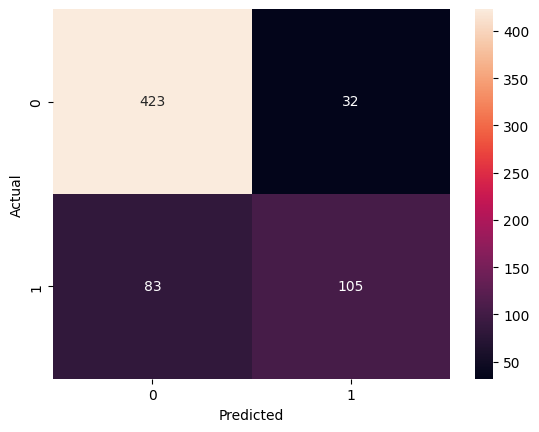

In [36]:
cm = confusion_matrix(target_test, target_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

- El valor 32 indica que el modelo predice 32 veces en el conjunto de prueba como plan Ultra y en realidad es plan Smart. Es decir, se equivoca.
- El valor 423 indica que el modelo predice 423 veces en el conjunto de prueba como plan Smart y en realidad es plan Smart. Es decir, lo hace bien.
- El valor 83 indica que el modelo predice 83 veces en el conjunto de prueba como plan Smart y en realidad es plan Ultra. Es decir, se equivoca.
- El valor 105 indica que el modelo predice 105 veces en el conjunto de prueba como plan Ultra y en realidad es plan Ultra. Es decir, lo hace bien.